# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdelrhman-Moubarak/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup

In [2]:
import duckdb
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
hf_token = os.getenv('HF_TOKEN')

con = duckdb.connect()
con.sql(f"CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

FACT_MARCH = 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
DIM_CONTENT = 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'

## 1. Question

**Research question:** Can an H1-only feature set predict H2 click decline with higher Precision@50 than the baseline rule

**Decision it supports:** a ranked queue an editor works top-down to prioritize refresh work. Note: is_declining is confidence that a content is going to decline, not magnitude of decline.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Data

**Tables:** fact_content_daily_performance (Mar 2026, H1 = Mar 1-15 features, H2 = Mar 16-31 label) and dim_content, joined on content_hash_id. **Excluded** total_clicks_h1 (83.8% zero, label-artifact), avg_engagement_rate_h1 (3.4% GA4 coverage), and search_volume (no clean gradient), all confirmed by the coverage.

In [4]:
#########################################################
print("=== BUILDING THE FRAME ===")

h1_full = con.sql(f"""
    WITH h1 AS (
        SELECT
            content_hash_id,
            client_hash_id,
            AVG(gsc_avg_position)   AS average_search_position,
            SUM(gsc_clicks)         AS total_clicks_h1,
            SUM(gsc_impressions)    AS total_impressions_h1,
            CASE WHEN SUM(ga4_sessions) > 0
                 THEN SUM(ga4_engaged_sessions) * 1.0 / SUM(ga4_sessions)
                 ELSE NULL
            END AS avg_engagement_rate_h1
        FROM read_parquet('{FACT_MARCH}')
        WHERE report_date BETWEEN '2026-03-01' AND '2026-03-15'
        GROUP BY content_hash_id, client_hash_id
    )
    SELECT
        h1.*,
        DATE_DIFF('day', dc.content_created_date, DATE '2026-03-01') AS content_age_days,
        dc.content_type,
        dc.search_volume
    FROM h1
    JOIN read_parquet('{DIM_CONTENT}') dc USING (content_hash_id)
""").df()

label_h2 = con.sql(f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_clicks) AS total_clicks_h2
    FROM read_parquet('{FACT_MARCH}')
    WHERE report_date BETWEEN '2026-03-16' AND '2026-03-31'
    GROUP BY content_hash_id, client_hash_id
""").df()

frame = h1_full.merge(label_h2, on=["content_hash_id", "client_hash_id"], how="inner")
frame = frame.sort_values(["client_hash_id", "content_hash_id"]).reset_index(drop=True)
H1_DAYS = 15
H2_DAYS = 16
frame["is_declining"] = (frame["total_clicks_h2"] / H2_DAYS < frame["total_clicks_h1"] / H1_DAYS).astype(int)

print("shape:", frame.shape)

#########################################################
print("\n=== COVERAGE CHECKS ===")

print("missing position pct:", frame["average_search_position"].isna().mean() * 100)
print("missing engagement pct:", frame["avg_engagement_rate_h1"].isna().mean() * 100)
print("zero clicks_h1 pct:", (frame["total_clicks_h1"] == 0).mean() * 100)
print("zero impressions_h1 pct:", (frame["total_impressions_h1"] == 0).mean() * 100)
print("null search_volume pct:", frame["search_volume"].isna().mean() * 100)

#########################################################
print("\n=== BUCKETING TOTAL_CLICKS_H1 (EXCLUDED) ===")

median_nz_clicks = frame.loc[frame["total_clicks_h1"] > 0, "total_clicks_h1"].median()
frame["click_bucket"] = "no_clicks"
frame.loc[(frame["total_clicks_h1"] > 0) & (frame["total_clicks_h1"] <= median_nz_clicks), "click_bucket"] = "low"
frame.loc[frame["total_clicks_h1"] > median_nz_clicks, "click_bucket"] = "high"
print(frame.groupby("click_bucket")["is_declining"].agg(["mean", "count"]))

#########################################################
print("\n=== AVG_ENGAGEMENT_RATE_H1 (EXCLUDED, TOO SPARSE TO BUCKET) ===")

print("non-null n:", frame["avg_engagement_rate_h1"].notna().sum(), "/", len(frame))

#########################################################
print("\n=== BUCKETING SEARCH_VOLUME (EXCLUDED) ===")

sv_valid = frame[frame["search_volume"].notna()].copy()
median_nz_sv = sv_valid.loc[sv_valid["search_volume"] > 0, "search_volume"].median()
sv_valid["sv_bucket"] = "zero"
sv_valid.loc[(sv_valid["search_volume"] > 0) & (sv_valid["search_volume"] <= median_nz_sv), "sv_bucket"] = "low"
sv_valid.loc[sv_valid["search_volume"] > median_nz_sv, "sv_bucket"] = "high"
print(sv_valid.groupby("sv_bucket")["is_declining"].agg(["mean", "count"]))

#########################################################
print("\n=== BUCKETING CONTENT_AGE_DAYS (KEPT) ===")

age_valid = frame[frame["content_age_days"] >= 0].copy()
age_valid["age_bucket"] = pd.qcut(age_valid["content_age_days"], q=3, labels=["young", "mid", "old"])
print(age_valid.groupby("age_bucket", observed=True)["is_declining"].agg(["mean", "count"]))

#########################################################
print("\n=== BUCKETING CONTENT_TYPE (KEPT) ===")

print(frame.groupby("content_type")["is_declining"].agg(["mean", "count"]).sort_values("mean", ascending=False))

#########################################################
print("\n=== BUCKETING TOTAL_IMPRESSIONS_H1 (KEPT) ===")

frame["has_impressions"] = (frame["total_impressions_h1"] > 0).astype(int)
active = frame[frame["has_impressions"] == 1].copy()
median_nz_impr = active["total_impressions_h1"].median()
active["impr_bucket"] = "low"
active.loc[active["total_impressions_h1"] > median_nz_impr, "impr_bucket"] = "high"
print("zero-activity decline rate:", frame.loc[frame["has_impressions"] == 0, "is_declining"].mean())
print(active.groupby("impr_bucket")["is_declining"].agg(["mean", "count"]))

#########################################################
print("\n=== BUCKETING AVERAGE_SEARCH_POSITION (KEPT, ACTIVE PAGES ONLY) ===")

pos_valid = active[active["average_search_position"].notna()].copy()
pos_valid["pos_bucket"] = pd.qcut(pos_valid["average_search_position"], q=3, labels=["top", "mid", "bottom"])
print(pos_valid.groupby("pos_bucket", observed=True)["is_declining"].agg(["mean", "count"]))

#########################################################
print("\n=== CANDIDATE FEATURES: BACKLINKS / WORD_COUNT / COMPETITION ===")

extra_cols = con.sql(f"""
    SELECT content_hash_id, backlinks, word_count, competition
    FROM read_parquet('{DIM_CONTENT}')
""").df()
candidate_test_frame = frame.merge(extra_cols, on="content_hash_id", how="left")

candidate_bucket_results = {}
candidate_columns = ["backlinks", "competition", "word_count"]
for col in candidate_columns:
    print("\n---", col, "---")
    valid = candidate_test_frame[candidate_test_frame[col].notna()].copy()
    valid["bucket"] = pd.qcut(valid[col].rank(method="first"), q=3, labels=["low", "mid", "high"])
    bucket_table = valid.groupby("bucket", observed=True)["is_declining"].agg(["mean", "count"])
    candidate_bucket_results[col] = bucket_table
    print("null pct:", candidate_test_frame[col].isna().mean() * 100)
    print(bucket_table)

#########################################################
print("=== CHECKING WORD_COUNT GRADIENT AGAINST ZERO-ACTIVITY OVERLAP ===")
   
wc_valid = candidate_test_frame[candidate_test_frame["word_count"].notna()].copy()
wc_valid["bucket"] = pd.qcut(wc_valid["word_count"].rank(method="first"), q=3, labels=["low", "mid", "high"])

crosstab = wc_valid.groupby("bucket", observed=True)["has_impressions"].agg(["mean", "count"])
print(crosstab)

#########################################################
print("\n=== WINDOW WIDENING TEST ===")

FACT_ALL = 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/data_0.parquet'
zero_impr_df = frame.loc[frame["has_impressions"] == 0, ["content_hash_id", "client_hash_id"]].drop_duplicates()
con.register("zero_impr_ids", zero_impr_df)

lookback_options = {"current (15d)": 15, "+30d": 30, "+60d": 60, "+90d": 90, "+180d": 180, "+365d": 365}
window_results = []
for label in lookback_options:
    days = lookback_options[label]
    n = con.sql(f"""
        SELECT COUNT(DISTINCT z.content_hash_id) FROM zero_impr_ids z
        JOIN read_parquet('{FACT_ALL}') f ON f.content_hash_id = z.content_hash_id AND f.client_hash_id = z.client_hash_id
        WHERE f.report_date BETWEEN (DATE '2026-03-15' - INTERVAL {days-1} DAY) AND DATE '2026-03-15' AND f.gsc_impressions > 0
    """).df().iloc[0, 0]
    pct_regained = n / len(zero_impr_df) * 100
    window_results.append({"window": label, "lookback_days": days, "pct_of_zero_group": round(pct_regained, 2)})

window_widening_df = pd.DataFrame(window_results)
print(window_widening_df)

h1_180 = con.sql(f"""
    SELECT content_hash_id, client_hash_id, COUNT(DISTINCT report_date) AS coverage_days_h1
    FROM read_parquet('{FACT_ALL}')
    WHERE report_date BETWEEN (DATE '2026-03-15' - INTERVAL 179 DAY) AND DATE '2026-03-15'
    GROUP BY 1, 2
""").df()
print("pct full 180d coverage:", (h1_180["coverage_days_h1"] >= 180).mean() * 100)
print("pct under 90d coverage:", (h1_180["coverage_days_h1"] < 90).mean() * 100)
print("median coverage days:", h1_180["coverage_days_h1"].median())

=== BUILDING THE FRAME ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

shape: (319758, 11)

=== COVERAGE CHECKS ===
missing position pct: 52.47030566866192
missing engagement pct: 84.19210778150976
zero clicks_h1 pct: 83.76709886851931
zero impressions_h1 pct: 52.47030566866192
null search_volume pct: 18.247549709467787

=== BUCKETING TOTAL_CLICKS_H1 (EXCLUDED) ===
                  mean   count
click_bucket                  
high          0.630364   21578
low           0.752539   30328
no_clicks     0.000000  267852

=== AVG_ENGAGEMENT_RATE_H1 (EXCLUDED, TOO SPARSE TO BUCKET) ===
non-null n: 50547 / 319758

=== BUCKETING SEARCH_VOLUME (EXCLUDED) ===
               mean   count
sv_bucket                  
high       0.143875   57842
low        0.155966   82691
zero       0.115630  120877

=== BUCKETING CONTENT_AGE_DAYS (KEPT) ===
                mean   count
age_bucket                  
young       0.176149  102493
mid         0.089142  100458
old         0.080118   99741

=== BUCKETING CONTENT_TYPE (KEPT) ===
                        mean   count
content_

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

          window  lookback_days  pct_of_zero_group
0  current (15d)             15               0.00
1           +30d             30               7.00
2           +60d             60              12.78
3           +90d             90              16.32
4          +180d            180              21.89
5          +365d            365              23.54


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

pct full 180d coverage: 4.32053088334537
pct under 90d coverage: 25.891218640114605
median coverage days: 131.0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

#########################################################
print("=== FEATURE ENGINEERING ===")

median_position = frame.loc[frame["has_impressions"] == 1, "average_search_position"].median()
frame["avg_position_h1"] = frame["average_search_position"]
frame.loc[frame["has_impressions"] == 0, "avg_position_h1"] = median_position

frame["avg_position_h1"] = frame["avg_position_h1"].round(6)

frame["age_x_impressions"] = frame["content_age_days"] * frame["total_impressions_h1"]

print("median position used for imputation:", median_position)
print("nulls remaining in avg_position_h1:", frame["avg_position_h1"].isna().sum())

#########################################################
print("\n=== BUILD MODEL FRAME ===")

feature_cols = ["content_age_days", "content_type", "total_impressions_h1", "has_impressions", "avg_position_h1", "age_x_impressions"]
model_frame = frame[feature_cols + ["is_declining", "client_hash_id", "content_hash_id"]].dropna(subset=["content_age_days"])
model_frame = model_frame[model_frame["content_age_days"] >= 0]
model_frame = pd.get_dummies(model_frame, columns=["content_type"], drop_first=True)

dupe_check_cols = []
for col in model_frame.columns:
    if col != "client_hash_id" and col != "content_hash_id":
        dupe_check_cols.append(col)

print("model_frame shape:", model_frame.shape)
print("distinct clients:", model_frame["client_hash_id"].nunique())
print("duplicate feature rows:", model_frame.duplicated(subset=dupe_check_cols).sum())

#########################################################
print("\n=== CLIENT HOLDOUT SPLIT ===")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_frame, groups=model_frame["client_hash_id"]))
train, test = model_frame.iloc[train_idx], model_frame.iloc[test_idx]

overlap_clients = set(train["client_hash_id"]) & set(test["client_hash_id"])
print("train shape:", train.shape)
print("test shape:", test.shape)
print("clients in train:", train["client_hash_id"].nunique())
print("clients in test:", test["client_hash_id"].nunique())
print("clients overlapping train and test:", len(overlap_clients))
print("train decline rate:", train["is_declining"].mean())
print("test decline rate:", test["is_declining"].mean())


=== FEATURE ENGINEERING ===
median position used for imputation: 8.285743145743146
nulls remaining in avg_position_h1: 0

=== BUILD MODEL FRAME ===
model_frame shape: (302692, 10)
distinct clients: 52
duplicate feature rows: 166760

=== CLIENT HOLDOUT SPLIT ===
train shape: (249445, 10)
test shape: (53247, 10)
clients in train: 41
clients in test: 11
clients overlapping train and test: 0
train decline rate: 0.11765719898173946
test decline rate: 0.10612804477247545


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [7]:
#########################################################
print("=== BUILD BASELINE RULE ===")

rule_frame = frame[frame["content_age_days"] >= 0].copy()
rule_frame["age_bucket"] = pd.qcut(rule_frame["content_age_days"], q=3, labels=["young", "mid", "old"])
age_points = {"young": 3, "mid": 1, "old": 0}
type_points = {"keyword article": 2, "comparison article": 1, "feedly article": 0}
rule_frame["age_points"] = rule_frame["age_bucket"].map(age_points)
rule_frame["type_points"] = rule_frame["content_type"].map(type_points)
rule_frame["score"] = rule_frame["age_points"].astype(float) + rule_frame["type_points"].astype(float)
rule_frame["action"] = "no_action"
rule_frame.loc[rule_frame["score"] >= 2, "action"] = "monitor"
rule_frame.loc[rule_frame["score"] >= 4, "action"] = "refresh"
print("rows in rule_frame:", len(rule_frame))
print(rule_frame["action"].value_counts())

#########################################################
print("\n=== BASELINE RULE TIER-LEVEL PRECISION ===")

rule_test = rule_frame[rule_frame["content_hash_id"].isin(test["content_hash_id"])]
refresh_tier = rule_test[rule_test["action"] == "refresh"]
print("refresh tier size:", len(refresh_tier))
print("refresh tier precision:", refresh_tier["is_declining"].mean())
print("random guessing rate:", rule_test["is_declining"].mean())
print("lift:", refresh_tier["is_declining"].mean() / rule_test["is_declining"].mean())

#########################################################
print("\n=== BASELINE RULE FORCED PRECISION@50 (JUST FOR SHOWCASE) ===")

rule_test_sorted = rule_test.sort_values(["score", "content_hash_id"], ascending=[False, True]).reset_index(drop=True)
n_tied_at_top = (rule_test_sorted["score"] == rule_test_sorted["score"].max()).sum()
top50_rule = rule_test_sorted.head(50)
precision_at_50_rule = top50_rule["is_declining"].mean()
print("rows tied at the top score:", n_tied_at_top)
print("pool size:", len(rule_test_sorted))
print("forced precision at 50:", precision_at_50_rule)
print("declines in top 50:", top50_rule["is_declining"].sum())

#########################################################
print("\n=== HYPERPARAMETER TUNING SWEEP: 5-FOLD GroupKFold CROSS VALIDATION ===")

from sklearn.model_selection import GroupKFold
import numpy as np

def precision_at_50(mdl, X_tr, y_tr, X_te, y_te, ids_te):
    mdl.fit(X_tr, y_tr)
    probs = mdl.predict_proba(X_te)[:, 1]
    res = pd.DataFrame({"content_hash_id": ids_te, "is_declining": y_te.values, "predicted_prob": probs})
    res = res.sort_values(["predicted_prob", "content_hash_id"], ascending=[False, True]).reset_index(drop=True)
    return res.head(50)["is_declining"].mean()

drop_cols = ["is_declining", "client_hash_id", "content_hash_id"]
X_all = model_frame.drop(columns=drop_cols)
y_all = model_frame["is_declining"]
groups_all = model_frame["client_hash_id"]
ids_all = model_frame["content_hash_id"]

gkf = GroupKFold(n_splits=5)
max_depth_grid = [3, 5, 8, 12, None]
min_leaf_grid = [1, 5, 20, 50]

sweep_results = []
for max_depth in max_depth_grid:
    for min_leaf in min_leaf_grid:
        fold_scores = []
        for tr_idx, te_idx in gkf.split(X_all, y_all, groups=groups_all):
            X_tr = X_all.iloc[tr_idx]
            y_tr = y_all.iloc[tr_idx]
            X_te = X_all.iloc[te_idx]
            y_te = y_all.iloc[te_idx]
            ids_te = ids_all.iloc[te_idx]
            sweep_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced",
                                                  n_jobs=-1, max_depth=max_depth, min_samples_leaf=min_leaf)
            score = precision_at_50(sweep_model, X_tr, y_tr, X_te, y_te, ids_te)
            fold_scores.append(score)
        sweep_results.append({"max_depth": max_depth, "min_samples_leaf": min_leaf,
                               "mean_precision_at_50": np.mean(fold_scores), "std_precision_at_50": np.std(fold_scores)})

sweep_df = pd.DataFrame(sweep_results)
sweep_df["mean_minus_std"] = sweep_df["mean_precision_at_50"] - sweep_df["std_precision_at_50"]
sweep_df = sweep_df.sort_values("mean_minus_std", ascending=False).reset_index(drop=True)
print(sweep_df)

#########################################################
print("\n=== PICK FINAL CONFIG: BEST MEAN-STD ===")

chosen_row = sweep_df.iloc[[0]]
chosen_max_depth = chosen_row["max_depth"].values[0]
chosen_min_leaf = chosen_row["min_samples_leaf"].values[0]
if pd.isna(chosen_max_depth):
    chosen_max_depth = None
else:
    chosen_max_depth = int(chosen_max_depth)
chosen_min_leaf = int(chosen_min_leaf)

print("chosen max_depth:", chosen_max_depth)
print("chosen min_samples_leaf:", chosen_min_leaf)
print(chosen_row[["mean_precision_at_50", "std_precision_at_50", "mean_minus_std"]])

#########################################################
print("\n=== MODEL TRAINING AND TESTING ===")

X_train, y_train = train.drop(columns=drop_cols), train["is_declining"]
X_test, y_test = test.drop(columns=drop_cols), test["is_declining"]

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced",
                                n_jobs=1, max_depth=chosen_max_depth, min_samples_leaf=chosen_min_leaf)
model.fit(X_train, y_train)
test_probs = model.predict_proba(X_test)[:, 1]

results_frame = X_test.copy()
results_frame["is_declining"] = y_test.values
results_frame["predicted_prob"] = test_probs
results_frame["content_hash_id"] = test["content_hash_id"].values
results_frame = results_frame.sort_values(["predicted_prob", "content_hash_id"], ascending=[False, True]).reset_index(drop=True)

print("distinct predicted probabilities:", results_frame["predicted_prob"].nunique())

#########################################################
print("\n=== MODEL'S PRECISION@50 ===")

top50_model = results_frame.head(50)
precision_at_50_model = top50_model["is_declining"].mean()
print("precision at 50:", precision_at_50_model)
print("declines in top 50:", top50_model["is_declining"].sum())
print("baseline rule (tier-level):", refresh_tier["is_declining"].mean())
print("lift over baseline rule (tier-level):", precision_at_50_model / refresh_tier["is_declining"].mean())

#########################################################
print("\n=== SUMMARY ===")

summary = pd.DataFrame([
    {"method": "Baseline: refresh tier precision", "value": refresh_tier["is_declining"].mean()},
    {"method": "Baseline: forced top-50 illustrative", "value": precision_at_50_rule},
    {"method": "Model: Precision@50 (single split)", "value": precision_at_50_model},
    {"method": "Model: CV mean Precision@50", "value": chosen_row["mean_precision_at_50"].values[0]},
    {"method": "lift over baseline rule (tier-level)", "value": precision_at_50_model / refresh_tier["is_declining"].mean()},
])
print(summary)


#########################################################
print("\n=== ADDING THE EXCLUDED NON-GSC COLUMNS ===")

extra_cols_test = con.sql(f"""
    SELECT content_hash_id, search_volume, backlinks, word_count, competition
    FROM read_parquet('{DIM_CONTENT}')
""").df()

model_frame_extra = frame[feature_cols + ["is_declining", "client_hash_id", "content_hash_id"]].dropna(subset=["content_age_days"])
model_frame_extra = model_frame_extra[model_frame_extra["content_age_days"] >= 0]
model_frame_extra = model_frame_extra.merge(extra_cols_test, on="content_hash_id", how="left")
model_frame_extra = model_frame_extra.dropna(subset=["search_volume", "backlinks", "word_count", "competition"])
model_frame_extra = pd.get_dummies(model_frame_extra, columns=["content_type"], drop_first=True)

gss_extra = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_extra, test_idx_extra = next(gss_extra.split(model_frame_extra, groups=model_frame_extra["client_hash_id"]))
train_extra, test_extra = model_frame_extra.iloc[train_idx_extra], model_frame_extra.iloc[test_idx_extra]

drop_cols_extra = ["is_declining", "client_hash_id", "content_hash_id"]
extra_only_cols = ["search_volume", "backlinks", "word_count", "competition"]
original_cols_only = [c for c in model_frame_extra.columns if c not in drop_cols_extra and c not in extra_only_cols]

# Model A: EXTRA features, RESTRICTED population
X_train_extra = train_extra.drop(columns=drop_cols_extra)
y_train_extra = train_extra["is_declining"]
X_test_extra = test_extra.drop(columns=drop_cols_extra)
y_test_extra = test_extra["is_declining"]

model_extra = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced",
                                      n_jobs=1, max_depth=chosen_max_depth, min_samples_leaf=chosen_min_leaf)
model_extra.fit(X_train_extra, y_train_extra)
probs_extra = model_extra.predict_proba(X_test_extra)[:, 1]

results_extra = X_test_extra.copy()
results_extra["is_declining"] = y_test_extra.values
results_extra["predicted_prob"] = probs_extra
results_extra = results_extra.sort_values("predicted_prob", ascending=False).reset_index(drop=True)
precision_at_50_extra = results_extra.head(50)["is_declining"].mean()

# Model B: ORIGINAL features, RESTRICTED population
X_train_restricted = train_extra[original_cols_only]
X_test_restricted = test_extra[original_cols_only]

model_restricted = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced",
                                           n_jobs=1, max_depth=chosen_max_depth, min_samples_leaf=chosen_min_leaf)
model_restricted.fit(X_train_restricted, y_train_extra)
probs_restricted = model_restricted.predict_proba(X_test_restricted)[:, 1]

results_restricted = X_test_restricted.copy()
results_restricted["is_declining"] = y_test_extra.values
results_restricted["predicted_prob"] = probs_restricted
results_restricted = results_restricted.sort_values("predicted_prob", ascending=False).reset_index(drop=True)
precision_restricted_original_features = results_restricted.head(50)["is_declining"].mean()

print("rows remaining after requiring all non-GSC columns present:", len(model_frame_extra))
print("has_impressions rate, full population:", model_frame["has_impressions"].mean())
print("has_impressions rate, restricted population:", model_frame_extra["has_impressions"].mean())
print()
print("precision at 50, ORIGINAL features, FULL population:", precision_at_50_model)
print("precision at 50, ORIGINAL features, RESTRICTED population:", precision_restricted_original_features)
print("precision at 50, EXTRA features, RESTRICTED population:", precision_at_50_extra)
print()
print("the jump comes from testing on an easier, restricted population, not from the extra columns")


=== BUILD BASELINE RULE ===
rows in rule_frame: 302692
action
monitor      166124
refresh       95047
no_action     41521
Name: count, dtype: int64

=== BASELINE RULE TIER-LEVEL PRECISION ===
refresh tier size: 14561
refresh tier precision: 0.15266808598310555
random guessing rate: 0.10612804477247545
lift: 1.4385272649694605

=== BASELINE RULE FORCED PRECISION@50 (JUST FOR SHOWCASE) ===
rows tied at the top score: 11176
pool size: 53247
forced precision at 50: 0.26
declines in top 50: 13

=== HYPERPARAMETER TUNING SWEEP: 5-FOLD GroupKFold CROSS VALIDATION ===
    max_depth  min_samples_leaf  mean_precision_at_50  std_precision_at_50  \
0         8.0                20                 0.652             0.085417   
1         8.0                 5                 0.668             0.114961   
2         NaN                20                 0.600             0.052154   
3         8.0                50                 0.620             0.076942   
4         8.0                 1            

## 5. Limitations

*What this work cannot claim.*

In [8]:
#########################################################
print("=== LIMITATION 1: FEATURE COLLISION ===")

base_id_cols = ("client_hash_id", "content_hash_id")
current_feature_cols = [c for c in model_frame.columns if c not in base_id_cols]
print("duplicate feature rows pct:", model_frame.duplicated(subset=current_feature_cols).mean() * 100)
print("zero-impression rows pct:", (model_frame["has_impressions"] == 0).mean() * 100)

print("\nsearch_volume: no clean gradient, see Data section")

for col in candidate_columns:
    print("\n" + col + " bucket decline rates:")
    print(candidate_bucket_results[col]["mean"])


print("\nwindow widening:")
print(window_widening_df)

#########################################################
print("\n=== LIMITATION 2: SMALL CLIENT POOL ===")

total_clients = model_frame["client_hash_id"].nunique()
print("total clients:", total_clients)

fold_client_counts = []
for tr_idx, te_idx in gkf.split(model_frame, groups=groups_all):
    fold_client_counts.append(groups_all.iloc[te_idx].nunique())
print("clients per CV fold:", fold_client_counts)

print("chosen config CV mean and std:")
print(chosen_row[["mean_precision_at_50", "std_precision_at_50"]])

#########################################################
print("\n=== LIMITATION 3: METRIC GRANULARITY VS FOLD VARIANCE ===")

step_size = 1 / 50
chosen_std = chosen_row["std_precision_at_50"].values[0]
print("Precision@50 step size:", step_size)
print("chosen config std:", chosen_std)

top_mean = sweep_df["mean_precision_at_50"].max()
close_configs = sweep_df[sweep_df["mean_precision_at_50"] >= top_mean - 0.1]
print("configs within 0.1 of top mean:", len(close_configs), "out of", len(sweep_df))

=== LIMITATION 1: FEATURE COLLISION ===
duplicate feature rows pct: 55.0923050493571
zero-impression rows pct: 52.22139997092754

search_volume: no clean gradient, see Data section

backlinks bucket decline rates:
bucket
low     0.157788
mid     0.143624
high    0.160420
Name: mean, dtype: float64

competition bucket decline rates:
bucket
low     0.101518
mid     0.169976
high    0.132424
Name: mean, dtype: float64

word_count bucket decline rates:
bucket
low     0.029745
mid     0.188241
high    0.177137
Name: mean, dtype: float64

window widening:
          window  lookback_days  pct_of_zero_group
0  current (15d)             15               0.00
1           +30d             30               7.00
2           +60d             60              12.78
3           +90d             90              16.32
4          +180d            180              21.89
5          +365d            365              23.54

=== LIMITATION 2: SMALL CLIENT POOL ===
total clients: 52
clients per CV fold: [10, 9,

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
#########################################################
print("=== BUILD THE RANKED ACTION QUEUE (test set, illustrative deployment example) ===")

queue = results_frame.copy()

queue["reason"] = "no_search_visibility"

active_mask = queue["has_impressions"] == 1
active_pool = queue[active_mask]

impr_high_cut = active_pool["total_impressions_h1"].quantile(2 / 3)
pos_bad_cut = active_pool["avg_position_h1"].quantile(2 / 3)
age_old_cut = active_pool["content_age_days"].quantile(2 / 3)

is_high_traffic = queue["total_impressions_h1"] >= impr_high_cut
is_poor_position = queue["avg_position_h1"] >= pos_bad_cut
is_old_content = queue["content_age_days"] >= age_old_cut

queue.loc[active_mask, "reason"] = "declining_search_signal"
queue.loc[active_mask & is_old_content, "reason"] = "aging_content_risk"
queue.loc[active_mask & is_poor_position, "reason"] = "poor_ranking_position"
queue.loc[active_mask & is_high_traffic, "reason"] = "high_traffic_at_risk"

queue["action"] = "no_action"
queue.loc[queue["reason"] == "no_search_visibility", "action"] = "manual_content_audit"

rankable = queue[queue["has_impressions"] == 1].reset_index(drop=True)
rankable.loc[rankable.index < 50, "action"] = "refresh_priority"
rankable.loc[(rankable.index >= 50) & (rankable.index < 200), "action"] = "monitor"

not_rankable = queue[queue["has_impressions"] == 0]

final_queue = pd.concat([rankable, not_rankable], ignore_index=True)

print("rows in rankable track:", len(rankable))
print("rows in manual-audit track (no search visibility):", len(not_rankable))
print(final_queue["action"].value_counts())
print("\nreason code breakdown (rankable track):")
print(rankable["reason"].value_counts())

#########################################################
print("\n=== TOP OF THE QUEUE (excerpt for the paper) ===")

top_of_queue = rankable.head(20)[["content_hash_id", "predicted_prob", "reason", "action"]]
print(top_of_queue.to_string(index=False))

#########################################################
print("\n=== CONFIDENCE NOTE ===")

print("refresh_priority tier size:", (rankable["action"] == "refresh_priority").sum())
print("precision within refresh_priority tier:", rankable.head(50)["is_declining"].mean())
print("CV mean/std for this config:", chosen_row[["mean_precision_at_50", "std_precision_at_50"]].values)
print("treat exact rank order as illustrative -- CV std shows fold-to-fold movement of this size")


=== BUILD THE RANKED ACTION QUEUE (test set, illustrative deployment example) ===
rows in rankable track: 24609
rows in manual-audit track (no search visibility): 28638
action
manual_content_audit    28638
no_action               24409
monitor                   150
refresh_priority           50
Name: count, dtype: int64

reason code breakdown (rankable track):
reason
declining_search_signal    8762
high_traffic_at_risk       8205
poor_ranking_position      5385
aging_content_risk         2257
Name: count, dtype: int64

=== TOP OF THE QUEUE (excerpt for the paper) ===
         content_hash_id  predicted_prob               reason           action
content_7de2236ec61ba4c5        0.924932 high_traffic_at_risk refresh_priority
content_4c8df2d73347920e        0.923069 high_traffic_at_risk refresh_priority
content_425a23ff83f9f448        0.922487 high_traffic_at_risk refresh_priority
content_48272175617ff8a4        0.922462 high_traffic_at_risk refresh_priority
content_3e84deb740299a26       

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

=== CHART 1: Baseline vs model Precision@50 ===


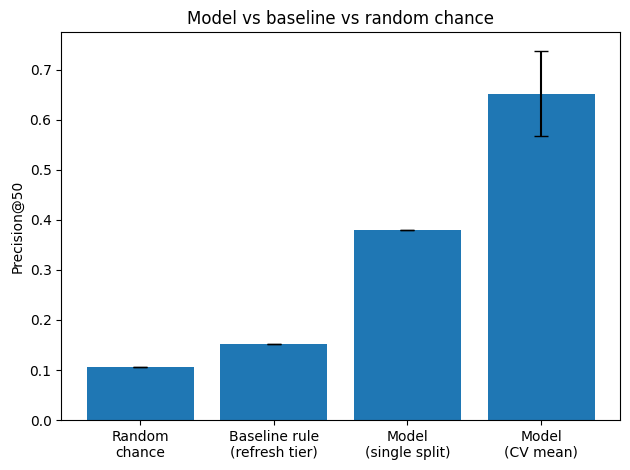


=== CHART 2: Feature collision ===


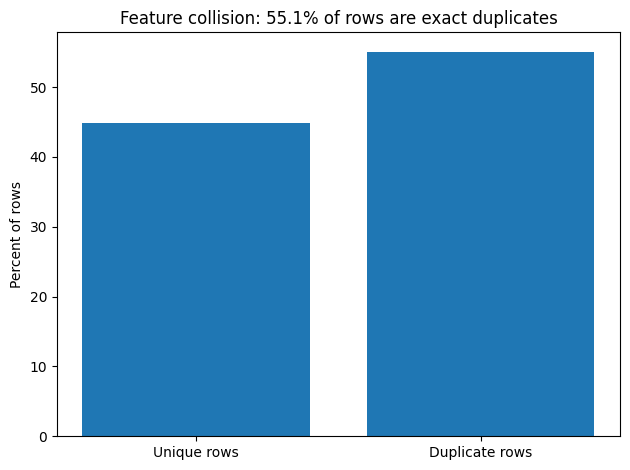


=== CHART 3: Window widening tradeoff ===


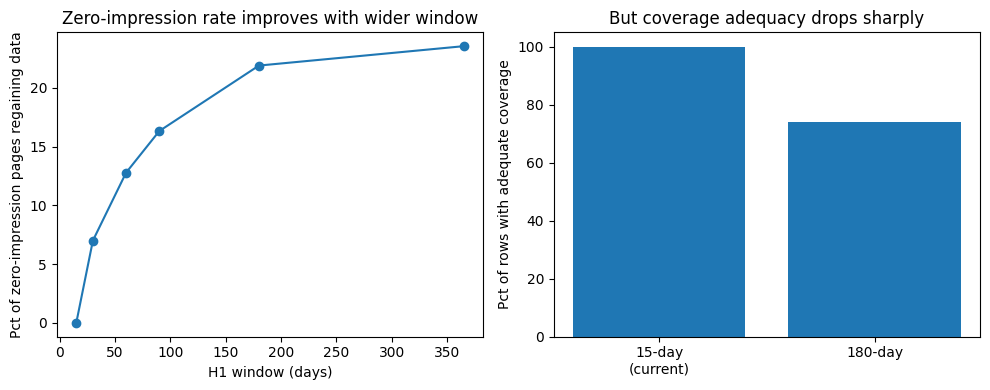


=== CHART 4: Hyperparameter sweep heatmap ===


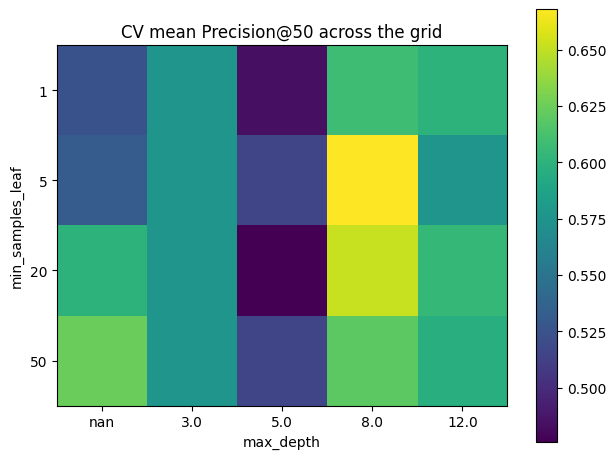


=== CHART 5: Candidate feature rejection (backlinks / competition / word_count) ===


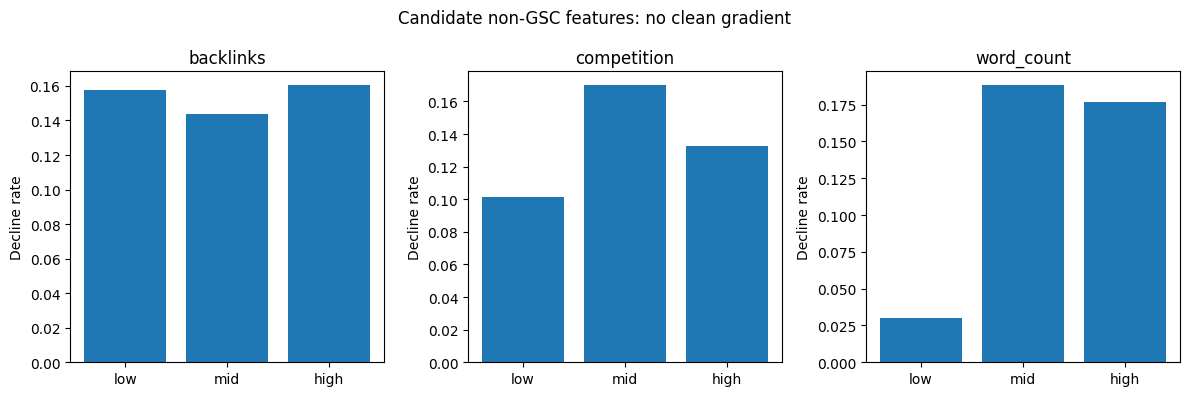


=== CHART 6: word_count / competition track has_impressions, not real decline signal ===


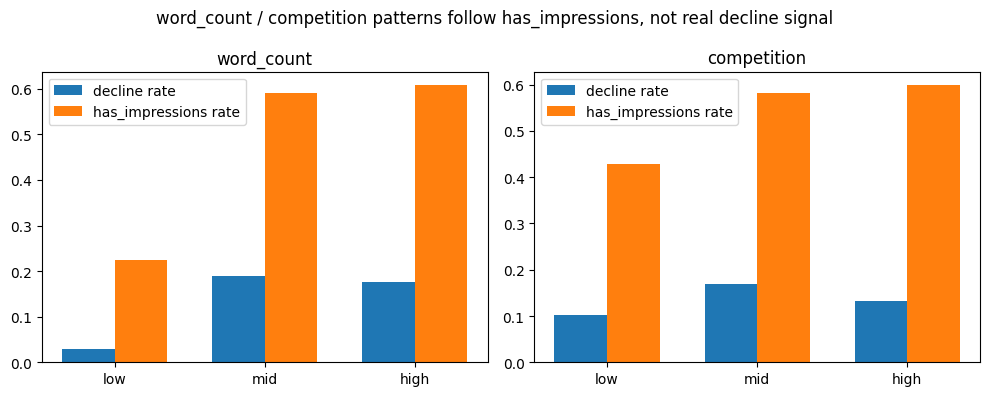


=== CHART 7: Feature importance ===


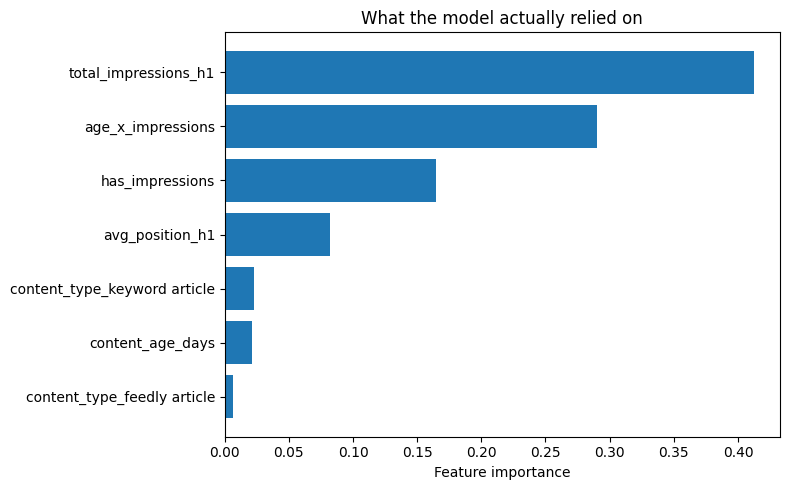


=== CHART 8: fairness check, population selection vs real signal ===


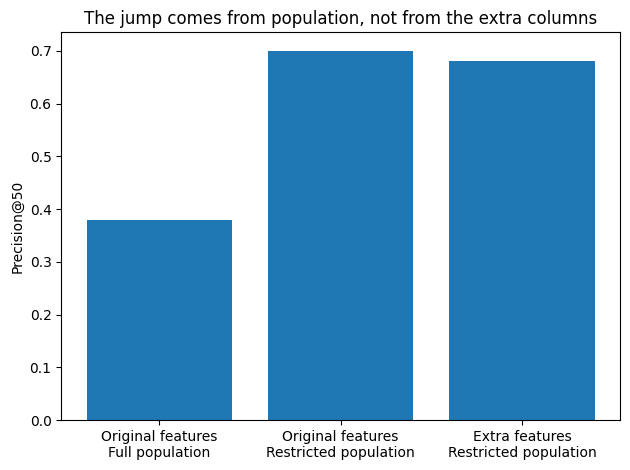

In [10]:
import matplotlib.pyplot as plt

#########################################################
print("=== CHART 1: Baseline vs model Precision@50 ===")

fig, ax = plt.subplots()
labels = ["Random\nchance", "Baseline rule\n(refresh tier)", "Model\n(single split)", "Model\n(CV mean)"]
values = [rule_test["is_declining"].mean(), refresh_tier["is_declining"].mean(), precision_at_50_model, chosen_row["mean_precision_at_50"].values[0]]
errors = [0, 0, 0, chosen_row["std_precision_at_50"].values[0]]
ax.bar(labels, values, yerr=errors, capsize=5)
ax.set_ylabel("Precision@50")
ax.set_title("Model vs baseline vs random chance")
plt.tight_layout()
plt.savefig("chart1_baseline_vs_model.png")
plt.show()

#########################################################
print("\n=== CHART 2: Feature collision ===")

dupe_pct = model_frame.duplicated(subset=current_feature_cols).mean() * 100
fig, ax = plt.subplots()
ax.bar(["Unique rows", "Duplicate rows"], [100 - dupe_pct, dupe_pct])
ax.set_ylabel("Percent of rows")
ax.set_title("Feature collision: " + str(round(dupe_pct, 1)) + "% of rows are exact duplicates")
plt.tight_layout()
plt.savefig("chart2_feature_collision.png")
plt.show()

#########################################################
print("\n=== CHART 3: Window widening tradeoff ===")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(window_widening_df["lookback_days"], window_widening_df["pct_of_zero_group"], marker="o")
axes[0].set_xlabel("H1 window (days)")
axes[0].set_ylabel("Pct of zero-impression pages regaining data")
axes[0].set_title("Zero-impression rate improves with wider window")

axes[1].bar(["15-day\n(current)", "180-day"], [100, 100 - 25.891218640114605])
axes[1].set_ylabel("Pct of rows with adequate coverage")
axes[1].set_title("But coverage adequacy drops sharply")
plt.tight_layout()
plt.savefig("chart3_window_widening.png")
plt.show()

#########################################################
print("\n=== CHART 4: Hyperparameter sweep heatmap ===")

pivot = sweep_df.pivot(index="min_samples_leaf", columns="max_depth", values="mean_precision_at_50")
fig, ax = plt.subplots()
im = ax.imshow(pivot.values, cmap="viridis")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title("CV mean Precision@50 across the grid")
fig.colorbar(im)
plt.tight_layout()
plt.savefig("chart4_hyperparameter_sweep.png")
plt.show()

#########################################################
print("\n=== CHART 5: Candidate feature rejection (backlinks / competition / word_count) ===")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(candidate_columns):
    means = candidate_bucket_results[col]["mean"]
    axes[i].bar(means.index.astype(str), means.values)
    axes[i].set_title(col)
    axes[i].set_ylabel("Decline rate")
plt.suptitle("Candidate non-GSC features: no clean gradient")
plt.tight_layout()
plt.savefig("chart5_candidate_features.png")
plt.show()


#########################################################
print("\n=== CHART 6: word_count / competition track has_impressions, not real decline signal ===")

bucket_order = ["low", "mid", "high"]

wc_valid_chart = candidate_test_frame[candidate_test_frame["word_count"].notna()].copy()
wc_valid_chart["bucket"] = pd.qcut(wc_valid_chart["word_count"].rank(method="first"), q=3, labels=bucket_order)
wc_decline = wc_valid_chart.groupby("bucket", observed=True)["is_declining"].mean().reindex(bucket_order)
wc_has_impr = wc_valid_chart.groupby("bucket", observed=True)["has_impressions"].mean().reindex(bucket_order)

comp_valid_chart = candidate_test_frame[candidate_test_frame["competition"].notna()].copy()
comp_valid_chart["bucket"] = pd.qcut(comp_valid_chart["competition"].rank(method="first"), q=3, labels=bucket_order)
comp_decline = comp_valid_chart.groupby("bucket", observed=True)["is_declining"].mean().reindex(bucket_order)
comp_has_impr = comp_valid_chart.groupby("bucket", observed=True)["has_impressions"].mean().reindex(bucket_order)

x = range(len(bucket_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([i - width/2 for i in x], wc_decline.values, width, label="decline rate")
axes[0].bar([i + width/2 for i in x], wc_has_impr.values, width, label="has_impressions rate")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(bucket_order)
axes[0].set_title("word_count")
axes[0].legend()

axes[1].bar([i - width/2 for i in x], comp_decline.values, width, label="decline rate")
axes[1].bar([i + width/2 for i in x], comp_has_impr.values, width, label="has_impressions rate")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bucket_order)
axes[1].set_title("competition")
axes[1].legend()

plt.suptitle("word_count / competition patterns follow has_impressions, not real decline signal")
plt.tight_layout()
plt.savefig("chart6_confound_check.png")
plt.show()

#########################################################
print("\n=== CHART 7: Feature importance ===")

importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values)
ax.set_xlabel("Feature importance")
ax.set_title("What the model actually relied on")
plt.tight_layout()
plt.savefig("chart7_feature_importance.png")
plt.show()


#########################################################
print("\n=== CHART 8: fairness check, population selection vs real signal ===")

fig, ax = plt.subplots()
labels = ["Original features\nFull population", "Original features\nRestricted population", "Extra features\nRestricted population"]
values = [precision_at_50_model, precision_restricted_original_features, precision_at_50_extra]
ax.bar(labels, values)
ax.set_ylabel("Precision@50")
ax.set_title("The jump comes from population, not from the extra columns")
plt.tight_layout()
plt.savefig("chart8_fairness_check.png")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.